# Bayesian inference with conjugacy or grid search

The simplest way to approximate Bayesian inference is with a _grid approximation_, in which we simply replace the integral with a sum, and compute $p(y\mid \theta)p(\theta)$ for a grid of possible values for $\theta$. How fine we make the resolution of this grid is a user setting, here I pick $n=100$. This is easy to implement, but doesn't work in higher dimensions (= when we have many unknown variables), because for $p$ variables, we have $n^p$ elements in our grid, whereas most elements in that grid are 'uninteresting' (= have low probability). In that situation, we have to use for instance MCMC.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.special import beta as B
plt.rc('axes', titlesize=24)        # fontsize of the axes title
plt.rc('axes', labelsize=20)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=18)       # fontsize of the tick labels
plt.rc('ytick', labelsize=18)       # fontsize of the tick labels
plt.rc('legend', fontsize=20)       # legend fontsize
plt.rc('figure', titlesize=36)      # fontsize of the figure title

We wish to know the coin flip probability $\theta$. Our experiment consists of $N=20$ coin flips, of which $z=5$ landed Heads. We have some prior belief that the coin is in fact fair, represented by $a=b=4$. We use a Bernoulli likelihood.

## A conjugate prior

First, we use a beta prior. 

In [79]:
z = 5
N = 20
a = b = 4

def bernoulli_likelihood(z, N, theta):
    # It is more numerically stable to compute the log-likelihood instead, but this will do for now.
    return theta**z * (1-theta)**(N-z)

def beta_distribution(theta, a, b):
    return theta**(a-1) * (1-theta)**(b-1) / B(a,b)

First, we plot the beta prior belief about $\theta$, and the Bernoulli likelihood given these observations. Note: since we cannot plot continuous functions on a discrete computer, we simply evaluate $\theta$ at lots ($n$) different locations. We also use this later in the grid search.

In [80]:
n = 100
# Make a grid of n possible values for theta, uniformly taken from the range of allowed values.
theta = np.linspace(0, 1, n)

prior = beta_distribution(theta, a, b)
likelihood = bernoulli_likelihood(z, N, theta)

Visualize the plots:

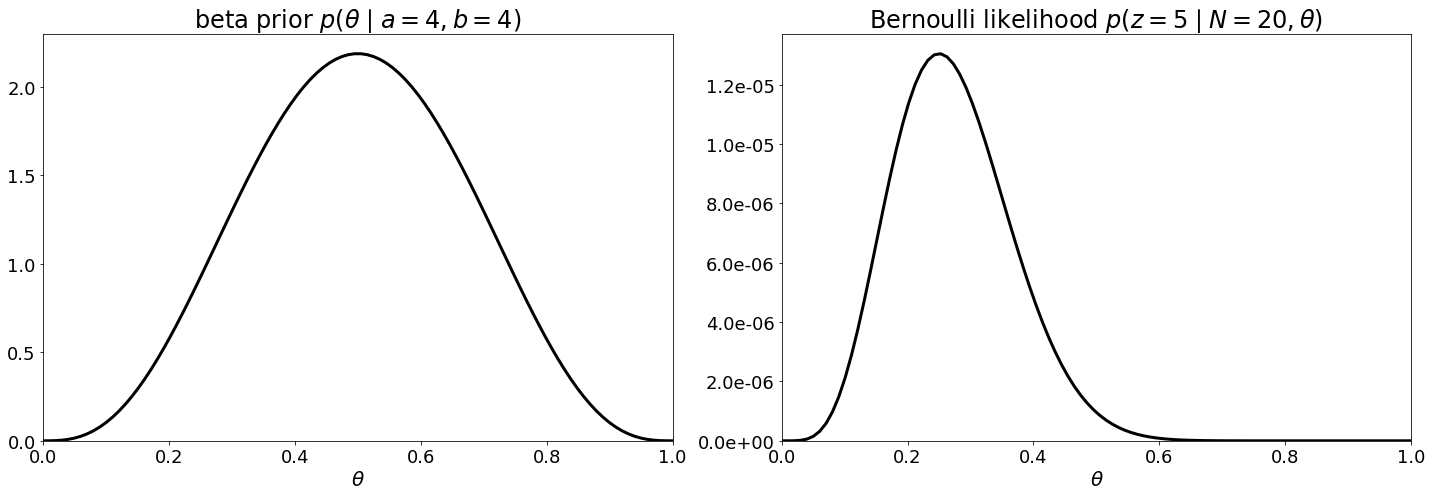

In [81]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,7), sharex=True)
axes[0].plot(theta, prior, lw=3, c='k')
axes[0].set_title('beta prior $p(\\theta\mid a={:d}, b={:d})$'.format(a, b))
axes[1].plot(theta, likelihood, lw=3, c='k')
axes[1].set_title('Bernoulli likelihood $p(z={:d}\mid N={:d}, \\theta)$'.format(z, N))
for ax in axes:
    ax.set_xlim([0, 1.0])
    ax.set_ylim(bottom=0)
    ax.set_xlabel('$\\theta$')
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1e'))
plt.tight_layout()

### Note 

The Bernoulli likelihood plot does not integrate to 1 here! Why could this be? (Remember lecture 2)

The answer is: because this likelihood is the conditional distribution $p(z\mid N, \theta$). This integrates to 1 when we integrate over $z$! Here, we simply show its value for $z=5$ for a range of different values for $\theta$.

Make sure you understand this behaviour - it will save you a lot of confusion later on ;-).

### Inference 
Now we do inference, i.e. we compute the posterior belief about $\theta$. Because the beta prior is conjugate to the Bernoulli likelihood, the resulting posterior is also a beta distribution:
$$
\begin{align}
    p(\theta \mid z, N) &= \frac{p(z\mid N, \theta)p(\theta\mid a, b)}{p(z\mid N, a, b)} \\
    &= \frac{\theta^{a-1+z} (1-\theta)^{b-1+N-z}}{B(a+z, b+N-z)} \\
    &= \text{beta}(\theta\mid a+z, b+N-z)\enspace.
\end{align}
$$

This Beta function $B(a+z, b+N-z)$ [we know how to solve](https://en.wikipedia.org/wiki/Beta_function), which makes it easy to compute for any $\theta$ its posterior probability. 

In [82]:
# For the proof, see Lecture 2.
posterior_conjugacy = beta_distribution(theta, a=a+z, b=N-z+b) # using conjugacy

Visualize (then execute):

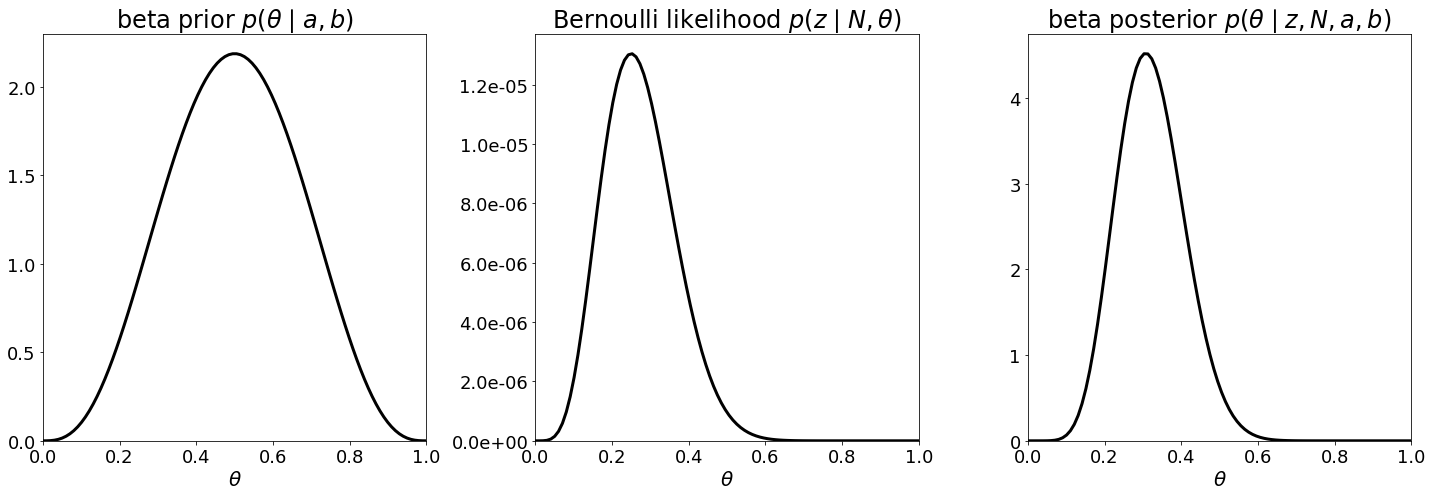

In [83]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,7), sharex=True)
axes[0].plot(theta, prior, lw=3, c='k')
axes[0].set_title('beta prior $p(\\theta\mid a, b)$')
axes[1].plot(theta, likelihood, lw=3, c='k')
axes[1].set_title('Bernoulli likelihood $p(z\mid N, \\theta)$')
axes[2].plot(theta, posterior_conjugacy, lw=3, c='k')
axes[2].set_title('beta posterior $p(\\theta\mid z, N, a, b)$')
for ax in axes:
    ax.set_xlim([0, 1.0])
    ax.set_ylim(bottom=0)
    ax.set_xlabel('$\\theta$')
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1e'))
plt.tight_layout()

---
## A difficult prior

But what if we had another prior? One that didn't result in integrals that we can easily solve? In cases with one or few parameters (here we have only $\theta$), we can do this with __grid approximation__.

Consider this prior distribution as an alternative to the beta prior:
$$
    p(\theta) =\frac{2}{3}(\cos( 4\pi\theta) + 1)^2  \enspace.
$$ 

The first step is to evaluate $p(z\mid N, \theta)p(\theta)$ at different discrete values for $\theta$. For plotting, we already had to make $\theta$ discrete anyway:

In [84]:
def weird_prior(theta):
    return 2/3* (np.cos(4*np.pi*theta)+1)**2

prior = weird_prior(theta)
posterior_grid_unnormalized = prior*likelihood 

This results in an _unnormalized_ posterior. But we can compute the normalization from our discrete result, like we can approximate any integral with a discrete sum:
$$
p(z\mid N) \approx \sum_{i=1}^n p(z\mid N, \theta_i) p(\theta_i) \Delta{\theta}
$$ where $\Delta{\theta}$ is the width of our discrete grid bins. We need this term to account for us approximating a continuous integral with a discrete sum - the approximation changes as we increase/decrease those bin sizes.

In [85]:
# Second, we normalize by dividing by the sum of all unnormalized values, as well as by the interval width,
# because we have approximated our continuous integral with discrete bins!
discrete_bin_width = theta[1] - theta[0]
normalization = np.sum(posterior_grid_unnormalized) * discrete_bin_width

We then obtain our grid-approximated posterior distribution (our end goal) by dividing by this normalization:

In [86]:
posterior_grid = posterior_grid_unnormalized / normalization

Visually:

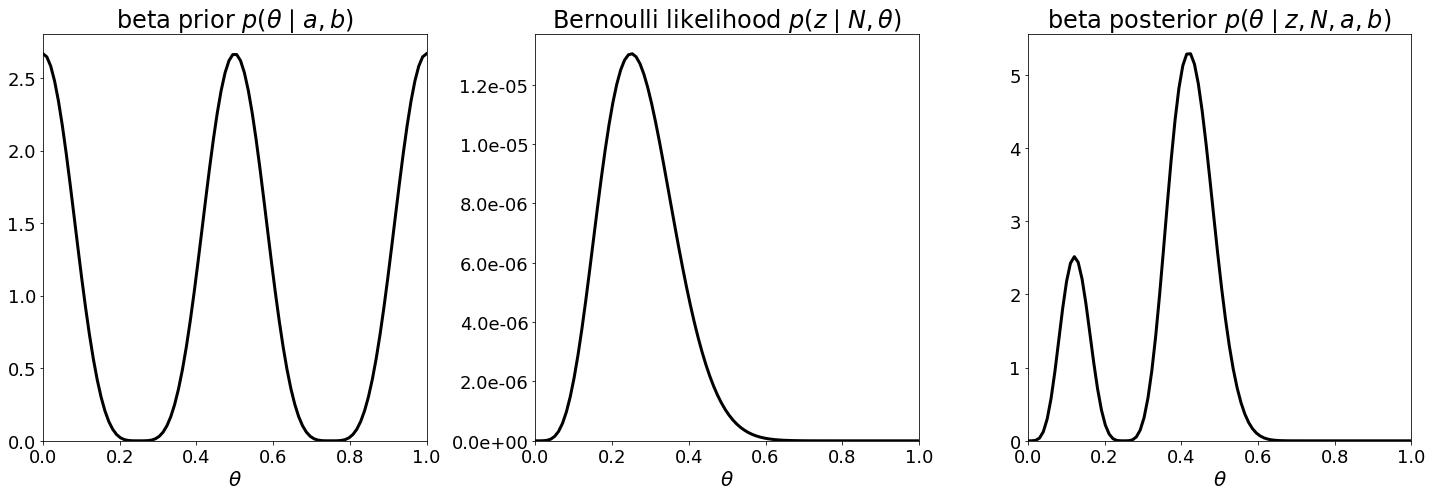

In [87]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,7), sharex=True)
axes[0].plot(theta, prior, lw=3, c='k')
axes[0].set_title('beta prior $p(\\theta\mid a, b)$')
axes[1].plot(theta, likelihood, lw=3, c='k')
axes[1].set_title('Bernoulli likelihood $p(z\mid N, \\theta)$')
axes[2].plot(theta, posterior_grid, lw=3, c='k')
axes[2].set_title('beta posterior $p(\\theta\mid z, N, a, b)$')
for ax in axes:
    ax.set_xlim([0, 1.0])
    ax.set_ylim(bottom=0)
    ax.set_xlabel('$\\theta$')
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1e'))
plt.tight_layout()

Note: this approach is crude, and there are much better ways to compute the integral (including methods based on numerical integration like we do here). But this is a good start!